In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Loading and Inspact

In [166]:
df = pd.read_csv("C:\\python libraries\\CSV files\\superstoreSales.csv", encoding='latin1')

In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   str    
 3   Order Priority        8399 non-null   str    
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   str    
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   str    
 12  Province              8399 non-null   str    
 13  Region                8399 non-null   str    
 14  Customer Segment      8399 non-null   str    
 15  Product Category      8399 non-n

In [168]:
df.describe()

,Row ID,Order ID,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost,Product Base Margin
count,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8336.000000
mean,4200.000000,29965.179783,25.571735,1775.878179,0.049671,181.184424,89.346259,12.838557,0.512513
std,2424.726789,17260.883447,14.481071,3585.050525,0.031823,1196.653371,290.354383,17.264052,0.135589
min,1.000000,3.000000,1.000000,2.240000,0.000000,-14140.700000,0.990000,0.490000,0.350000
25%,2100.500000,15011.500000,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000,0.380000
50%,4200.000000,29857.000000,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000,0.520000
75%,6299.500000,44596.000000,38.000000,1709.320000,0.080000,162.750000,85.990000,13.990000,0.590000
max,8399.000000,59973.000000,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000,0.850000


In [169]:
df.head(5)

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [170]:
df.shape

(8399, 21)

In [171]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Order Priority', 'Order Quantity',
       'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price',
       'Shipping Cost', 'Customer Name', 'Province', 'Region',
       'Customer Segment', 'Product Category', 'Product Sub-Category',
       'Product Name', 'Product Container', 'Product Base Margin',
       'Ship Date'],
      dtype='str')

In [172]:
df.dtypes

Row ID                    int64
Order ID                  int64
Order Date                  str
Order Priority              str
Order Quantity            int64
Sales                   float64
Discount                float64
Ship Mode                   str
Profit                  float64
Unit Price              float64
Shipping Cost           float64
Customer Name               str
Province                    str
Region                      str
Customer Segment            str
Product Category            str
Product Sub-Category        str
Product Name                str
Product Container           str
Product Base Margin     float64
Ship Date                   str
dtype: object

### Data Manipulation

In [173]:
df.duplicated().sum()

np.int64(0)

In [174]:
df.isnull().sum()

Row ID                   0
Order ID                 0
Order Date               0
Order Priority           0
Order Quantity           0
Sales                    0
Discount                 0
Ship Mode                0
Profit                   0
Unit Price               0
Shipping Cost            0
Customer Name            0
Province                 0
Region                   0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Name             0
Product Container        0
Product Base Margin     63
Ship Date                0
dtype: int64

In [175]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [176]:
df["Product Base Margin"] = df["Product Base Margin"].fillna(df["Product Base Margin"].mean())

### Data Analysis

In [177]:
#total sales by region
total_sales_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(2)

In [178]:
total_sales_region

Region
West                     3597549.28
Ontario                  3063212.48
Prarie                   2837304.60
Atlantic                 2014248.20
Quebec                   1510195.08
Yukon                     975867.37
Northwest Territories     800847.33
Nunavut                   116376.48
Name: Sales, dtype: float64

In [179]:
# Total sales by Category/Sub-Category
total_sales_category = df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)
total_sales_category


Product Category
Technology         5984248.182
Furniture          5178590.542
Office Supplies    3752762.100
Name: Sales, dtype: float64

In [180]:
total_sales_Sub_category = df.groupby('Product Sub-Category')['Sales'].sum().sort_values(ascending=False)
total_sales_Sub_category

Product Sub-Category
Office Machines                   2168697.140
Tables                            1896008.142
Telephones and Communication      1889313.802
Chairs & Chairmats                1761836.550
Copiers and Fax                   1130361.300
Storage & Organization            1070182.600
Binders and Binder Accessories    1022957.590
Bookcases                          822652.040
Computer Peripherals               795875.940
Appliances                         736991.540
Office Furnishings                 698093.810
Paper                              446452.860
Envelopes                          174085.800
Pens & Art Supplies                167107.220
Scissors, Rulers and Trimmers       80996.310
Labels                              38981.550
Rubber Bands                        15006.630
Name: Sales, dtype: float64

In [181]:
#Top 5 best-selling products
Top5_best_product = df.groupby("Product Name")["Sales"].count().sort_values(ascending=False).head(5)
Top5_best_product

Product Name
Global High-Back Leather Tilter, Burgundy                            24
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables    22
Bevis 36 x 72 Conference Tables                                      22
Fiskars¨ Softgrip Scissors                                           22
Master Giant Foot¨ Doorstop, Safety Yellow                           22
Name: Sales, dtype: int64

In [ ]:
#Monthly sales trend (extract month from date, groupby)
df["Month"] = df["Order Date"].dt.month

monthly_sales = df.groupby("Month")["Sales"].sum().round(2)
monthly_sales

Month
1     1444923.38
2     1180083.78
3     1273680.93
4     1216483.44
5     1160896.38
6     1030858.51
7     1141104.35
8     1115015.33
9     1337956.96
10    1383714.44
11    1163393.37
12    1467489.96
Name: Sales, dtype: float64

In [183]:
region_profit = df.groupby("Region")[["Sales", "Profit"]].sum().round(2)
category_profit = df.groupby("Product Category")[["Sales", "Profit"]].sum()


In [184]:
flagged = region_profit[
    (region_profit["Sales"] > 100000) &
    (region_profit["Profit"] < 10000)
]

flagged

,Sales,Profit
Region,,
Nunavut,116376.48,2841.11


In [185]:
flagged1 = category_profit[
    (category_profit["Sales"] > 1000000) &
    (category_profit["Profit"] < 500000)
]

flagged1

,Sales,Profit
Product Category,,
Furniture,5178590.542,117433.03


### Data Visualizations

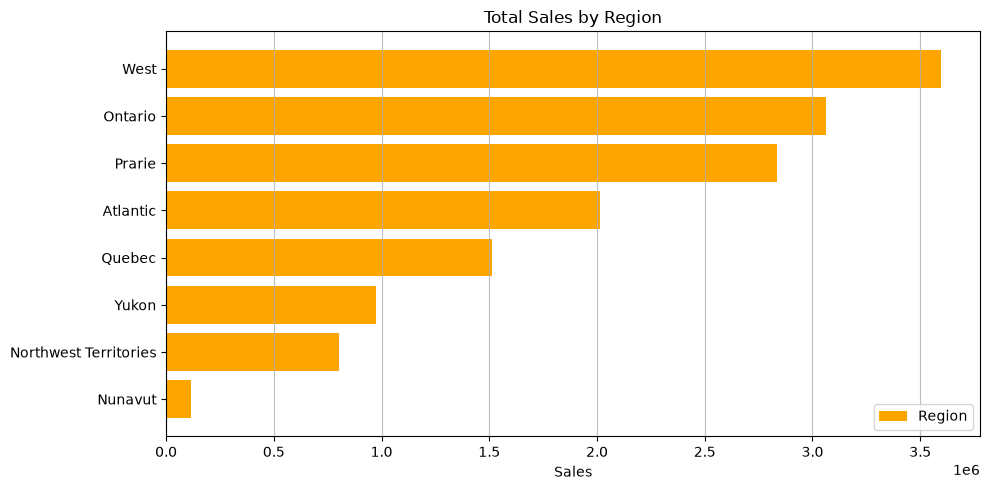

In [186]:
total_sales_region = total_sales_region.sort_values()

fig, ax = plt.subplots(figsize=(10, 5))

plt.barh(total_sales_region.index, total_sales_region.values, color="orange", label="Region")
plt.title("Total Sales by Region")
plt.xlabel("Sales")

plt.grid(axis='x', alpha=0.8)
plt.tight_layout()
plt.legend()

plt.show()

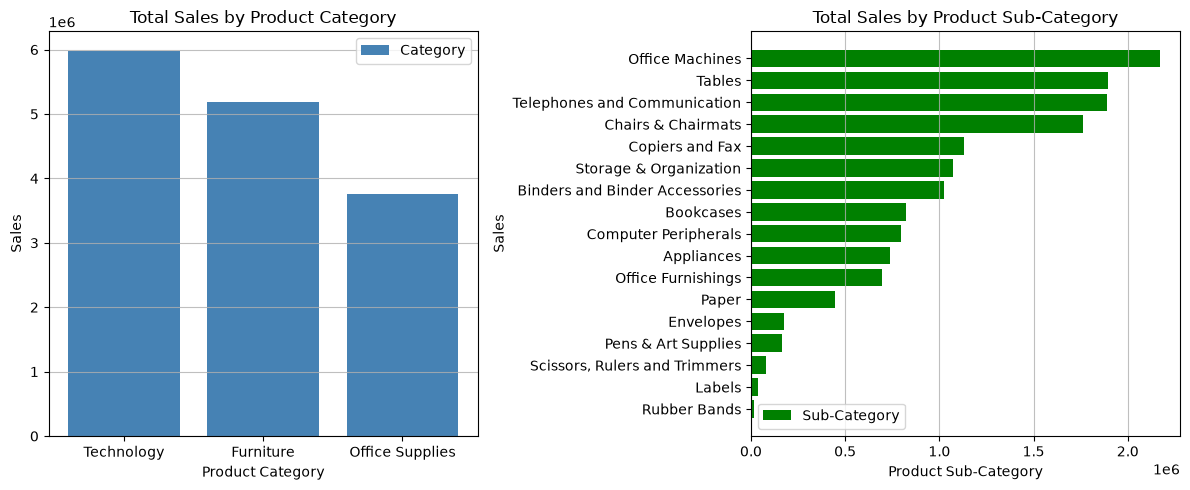

In [187]:
total_sales_Sub_category = total_sales_Sub_category.sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(total_sales_category.index, total_sales_category.values, color="steelblue", label="Category")
ax1.set_title("Total Sales by Product Category")
ax1.set_xlabel("Product Category")
ax1.set_ylabel("Sales")
ax1.grid(axis='y', alpha=0.8)
ax1.legend()

ax2.barh(total_sales_Sub_category.index, total_sales_Sub_category.values, color="green", label="Sub-Category")
ax2.set_title("Total Sales by Product Sub-Category")
ax2.set_xlabel("Product Sub-Category")
ax2.set_ylabel("Sales")
ax2.grid(axis='x', alpha=0.8)
ax2.legend()

plt.tight_layout()
plt.show()

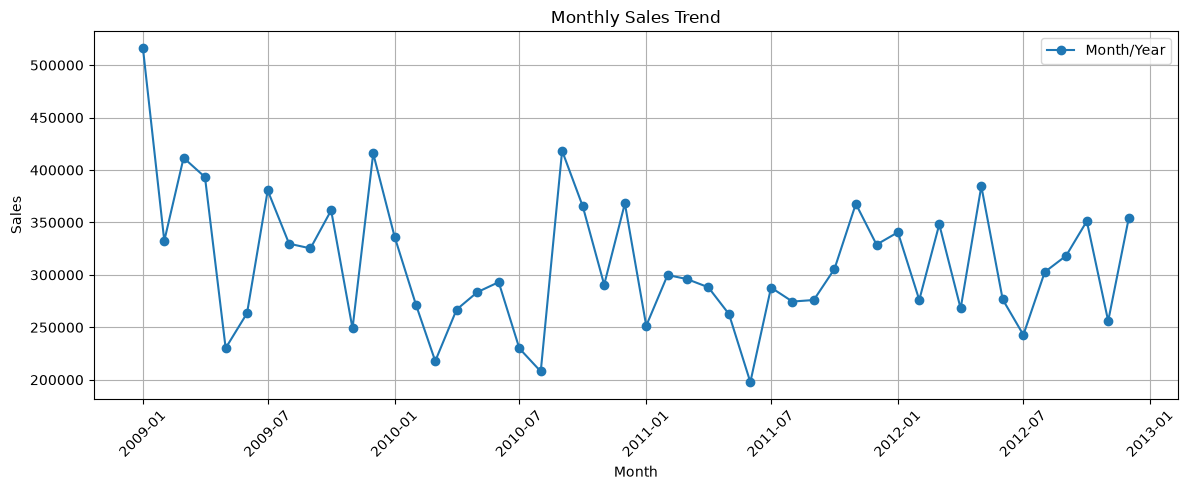

In [188]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
      .sum()
      .sort_index()
)

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    label="Month/Year"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")

plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

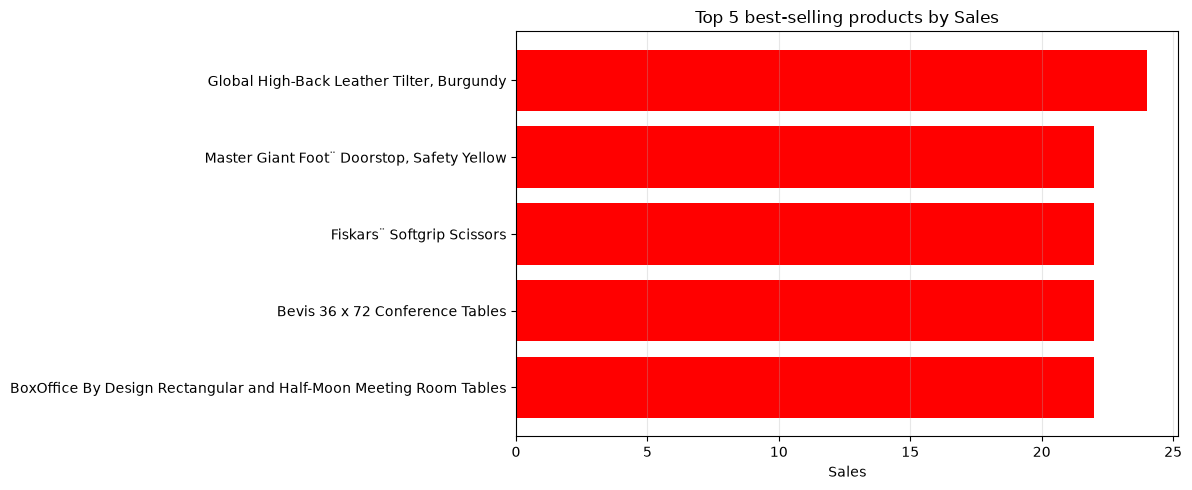

In [189]:
Top5_best_product = Top5_best_product.sort_values()

plt.figure(figsize=(12, 5))

plt.barh(Top5_best_product.index, Top5_best_product.values, color="red")
plt.title("Top 5 best-selling products by Sales")
plt.xlabel("Sales")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()